<a href="https://colab.research.google.com/github/Thisuka1103/Statistical-Learning-e22358/blob/main/Assignment%201/Assignment_1_E_22_358.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Q1) The Probability of Shooting at a Target**


A point is chosen at random from a disk of radius $10$. Let $A$ be the event that the point lies within $1$ unit of the boundary.

1. Model the experiment assuming the point is uniformly distributed with respect to area, and compute $P(A)$.
2. Model the experiment assuming the distance to the point from the center is chosen uniformly from $[0,10]$, and the direction is chosen independently and uniformly from $[0,2\pi)$ and compute $P(A)$.
3. Explain why the two answers differ.


## **Answer**

### Definitions: Sample Space and Event

Let the sample space $\Omega$ be the disk of radius 10 centered at the origin.
$$\Omega = \{(x,y) \in \mathbb{R}^2 : x^2 + y^2 \le 10^2\}$$

Let $A$ be the event that the randomly chosen point lies within 1 unit of the boundary. Since the total radius is 10, this means the distance from the center (let's call it $r$) must be between 9 and 10.
$$A = \{(x,y) \in \Omega : 9 \le \sqrt{x^2 + y^2} \le 10\}$$





### Part (a) : Uniform Distribution with Respect to Area

If the point is uniformly distributed with respect to the area, the probability of it falling in any region is proportional to the area of that region.

The total area of the sample space $\Omega$ is:
$$\text{Area}(\Omega) = \pi(10)^2 = 100\pi$$

The area of the region defining event $A$ (the outer annulus) is the area of the disk of radius 10 minus the area of the disk of radius 9:
$$\text{Area}(A) = \pi(10)^2 - \pi(9)^2 = 100\pi - 81\pi = 19\pi$$

The probability $P(A)$ is the ratio of these areas:
$$P(A) = \frac{\text{Area}(A)}{\text{Area}(\Omega)} = \frac{19\pi}{100\pi} = 0.19$$

###**Visualization  of part (a)**


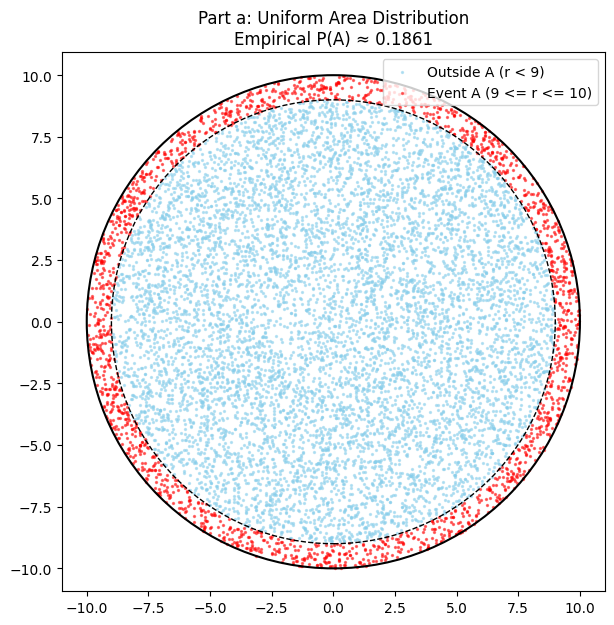

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set up parameters
N = 10000  # Number of points
R = 10     # Radius of the disk

# To generate uniform area points, scale the radius by the square root of a uniform distribution
u = np.random.uniform(0, 1, N)
r1 = R * np.sqrt(u)
theta1 = np.random.uniform(0, 2 * np.pi, N)

# Convert polar to Cartesian coordinates
x1 = r1 * np.cos(theta1)
y1 = r1 * np.sin(theta1)

# Identify points in Event A
in_A1 = (r1 >= 9) & (r1 <= 10)

# Plotting
plt.figure(figsize=(7, 7))
# Swapped LaTeX \le for standard <= to avoid parsing errors
plt.scatter(x1[~in_A1], y1[~in_A1], s=2, alpha=0.5, c='skyblue', label='Outside A (r < 9)')
plt.scatter(x1[in_A1], y1[in_A1], s=2, alpha=0.5, c='red', label='Event A (9 <= r <= 10)')

# Draw boundaries
plt.gca().add_patch(plt.Circle((0,0), 10, fill=False, color='black', linewidth=1.5))
plt.gca().add_patch(plt.Circle((0,0), 9, fill=False, linestyle='--', color='black'))

plt.title('Part a: Uniform Area Distribution\nEmpirical P(A) ≈ {:.4f}'.format(np.mean(in_A1)))
plt.axis('equal')
plt.legend(loc='upper right')
plt.show()

### Part (b): Uniform Distribution with Respect to Distance and Direction

In this model, the distance from the center $r$ and the angle $\theta$ are chosen uniformly and independently.
* $r \sim \text{Uniform}(0, 10)$
* $\theta \sim \text{Uniform}(0, 2\pi)$

Since event $A$ only depends on the radius ($9 \le r \le 10$), we only need to look at the distribution of $r$. The probability of picking a distance between 9 and 10 from a uniform distribution over $[0, 10]$ is simply the length of the favorable interval divided by the total interval length:

$$P(A) = \frac{\text{Favourable Length}}{\text{Total Length}} = \frac{10 - 9}{10 - 0} = \frac{1}{10} = 0.10$$

###**Visualization  of part (b)**

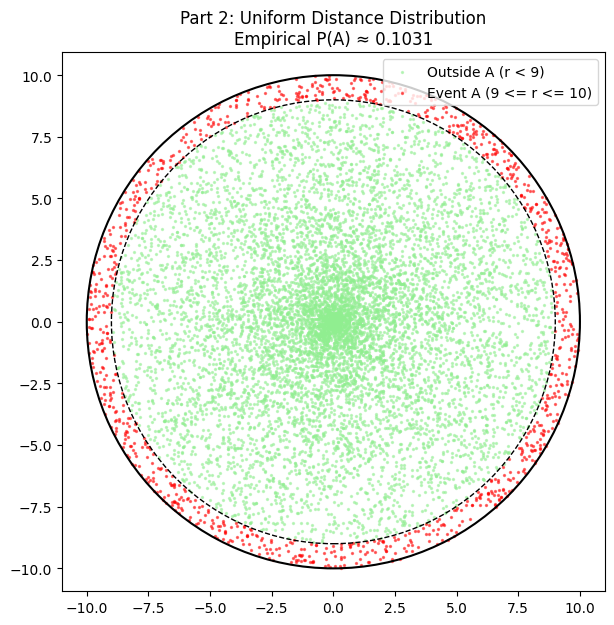

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Redefining parameters so this cell can run independently
N = 10000
R = 10

# Generate points with uniform distance
r2 = np.random.uniform(0, R, N)
theta2 = np.random.uniform(0, 2 * np.pi, N)

# Convert polar to Cartesian coordinates
x2 = r2 * np.cos(theta2)
y2 = r2 * np.sin(theta2)

# Identify points in Event A
in_A2 = (r2 >= 9) & (r2 <= 10)

# Plotting
plt.figure(figsize=(7, 7))
# Swapped LaTeX \le for standard <= to avoid parsing errors
plt.scatter(x2[~in_A2], y2[~in_A2], s=2, alpha=0.5, c='lightgreen', label='Outside A (r < 9)')
plt.scatter(x2[in_A2], y2[in_A2], s=2, alpha=0.5, c='red', label='Event A (9 <= r <= 10)')

# Draw boundaries
plt.gca().add_patch(plt.Circle((0,0), 10, fill=False, color='black', linewidth=1.5))
plt.gca().add_patch(plt.Circle((0,0), 9, fill=False, linestyle='--', color='black'))

plt.title('Part 2: Uniform Distance Distribution\nEmpirical P(A) ≈ {:.4f}'.format(np.mean(in_A2)))
plt.axis('equal')
plt.legend(loc='upper right')
plt.show()

### Part (c): Comparison of the Two Answers

The two answers differ significantly ($0.19$ vs $0.10$) because the two sampling methods create entirely different probability density profiles across the disk.

* **Uniform Area (Part 1):** Geometry dictates that the circumference (and thus the area of a thin ring) grows linearly as you move further from the center. To maintain an equal density of points per square unit of area, more points must be placed at the outer edges than at the center. This naturally inflates the probability of a point landing near the boundary ($19\%$).


* **Uniform Distance (Part 2):** By forcing the radius $r$ to be uniform, an equal number of points are placed in the ring from $r=1$ to $r=2$ as in the ring from $r=9$ to $r=10$. Because the inner rings have much less actual area, the points become heavily "clumped" or dense near the center, and sparse near the edges. This drops the probability of hitting the outer edge to just $10\%$.

###**Visualization  of part (c)**

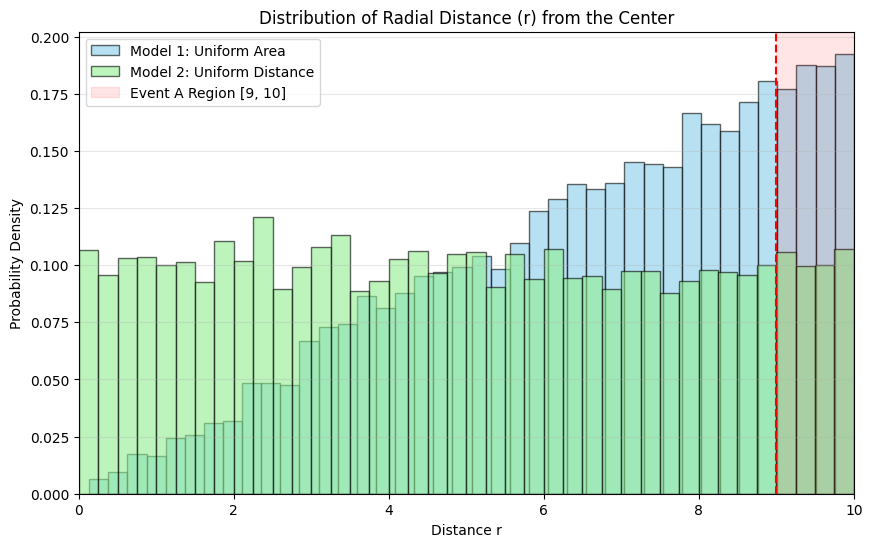

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# A quick check to ensure r1 and r2 exist if you run this cell first by accident
try:
    r1
    r2
except NameError:
    r1 = 10 * np.sqrt(np.random.uniform(0, 1, 10000))
    r2 = np.random.uniform(0, 10, 10000)

plt.figure(figsize=(10, 6))

# Plot density histograms for the radius of both models
plt.hist(r1, bins=40, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Model 1: Uniform Area')
plt.hist(r2, bins=40, density=True, alpha=0.6, color='lightgreen', edgecolor='black', label='Model 2: Uniform Distance')

# Highlight the target region (Event A)
plt.axvspan(9, 10, color='red', alpha=0.1, label='Event A Region [9, 10]')
plt.axvline(9, color='red', linestyle='dashed', linewidth=1.5)

plt.title('Distribution of Radial Distance (r) from the Center')
plt.xlabel('Distance r')
plt.ylabel('Probability Density')
plt.xlim(0, 10)
plt.legend(loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.show()

# **Q2) Bertrand's Paradox**

A chord of a circle is chosen “at random.” What is the probability that its length exceeds the side length of the inscribed equilateral triangle?

Show that different mathematically natural models of “random chord” lead to different answers.

## **Answer**

### Preliminary Geometric Facts

Let the circle be a unit circle centered at the origin with radius $R = 1$.

$$\Omega = \{(x,y) \in \mathbb{R}^2 : x^2 + y^2 \le 1\}$$
\
The side length of an equilateral triangle inscribed in this unit circle is $\sqrt{3}$.
Using basic geometry, a chord will be longer than $\sqrt{3}$ if and only if it is closer to the center than the side of the inscribed triangle. The perpendicular distance from the center to the side of the inscribed triangle is exactly $1/2$.


Therefore, for any model we define, our event of interest $A$ (the chord being longer than the triangle's side) is equivalent to:\
$$A = \{\text{perpendicular distance from center to chord} < 1/2\}$$

### Model 1: Random Endpoints

This model is often described more simply as:

* choose one endpoint uniformly on the circumference,
* then choose the other endpoint uniformly on the circumference.

By rotational symmetry, we may fix the first endpoint and choose the second uniformly.

---

**Probability space**

Let

$$
\Omega_1=[0,\pi]
$$

with Borel sigma-algebra

$$
\mathfrak A_1=\mathfrak B([0,\pi]),
$$

and probability measure

$$
P_1(E)=\frac{\lambda(E)}{\pi},
\qquad E\in\mathfrak A_1,
$$

where $\lambda$ is Lebesgue measure.

Interpret $\theta\in[0,\pi]$ as the smaller central angle subtended by the chord.

---

**Event**

A chord subtending angle $\theta$ has length

$$
L(\theta)=2\sin(\theta/2).
$$

We want

$$
L(\theta)>\sqrt{3}.
$$

Thus

$$
2\sin(\theta/2)>\sqrt{3}
$$

$$
\sin(\theta/2)>\frac{\sqrt{3}}{2}.
$$

Since $\theta/2\in[0,\pi/2]$, this is equivalent to

$$
\theta/2>\pi/3
\quad\Longleftrightarrow\quad
\theta>2\pi/3.
$$

So

$$
A_1=(2\pi/3,\pi].
$$

---

**Probability**

Therefore

$$
P_1(A_1)=\frac{\pi-2\pi/3}{\pi}=\frac{1}{3}.
$$

So under Model-1,

$$
\boxed{P_1(A_1)=\frac13}.
$$

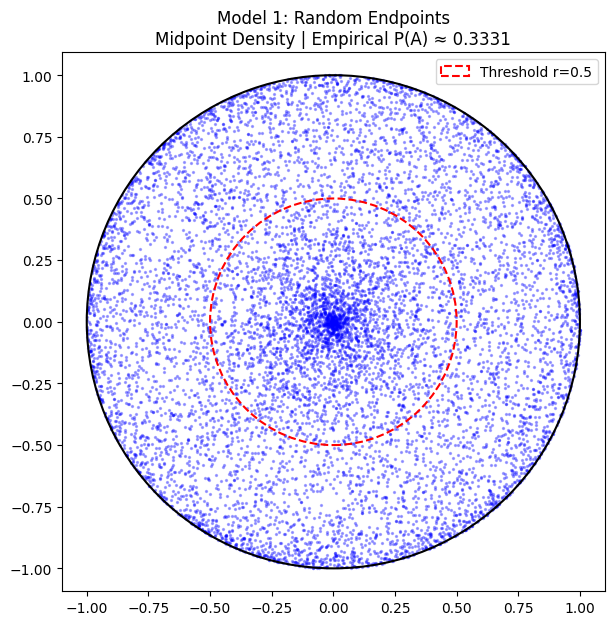

In [4]:
import numpy as np
import matplotlib.pyplot as plt

N_sim = 50000
N_plot = 10000 # We plot a subset so the graph isn't entirely black

# Model 1: Choose two random angles uniformly
theta1 = np.random.uniform(0, 2*np.pi, N_sim)
theta2 = np.random.uniform(0, 2*np.pi, N_sim)

# Calculate the midpoints of these chords
mid_x1 = (np.cos(theta1) + np.cos(theta2)) / 2
mid_y1 = (np.sin(theta1) + np.sin(theta2)) / 2

# Distance from center is the magnitude of the midpoint vector
dist1 = np.sqrt(mid_x1**2 + mid_y1**2)
prob1 = np.mean(dist1 < 0.5)

# Plotting
plt.figure(figsize=(7, 7))
plt.scatter(mid_x1[:N_plot], mid_y1[:N_plot], s=2, alpha=0.3, color='blue')

# Draw the main circle and the threshold circle (r=0.5)
plt.gca().add_patch(plt.Circle((0,0), 1, fill=False, color='black', linewidth=1.5))
plt.gca().add_patch(plt.Circle((0,0), 0.5, fill=False, color='red', linestyle='--', linewidth=1.5, label='Threshold r=0.5'))

plt.title('Model 1: Random Endpoints\nMidpoint Density | Empirical P(A) ≈ {:.4f}'.format(prob1))
plt.axis('equal')
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.legend(loc='upper right')
plt.show()

### Model-2: Random radius, then choose the chord perpendicular to it at a random point

This model is:

* choose a radius,
* choose a point uniformly along that radius,
* draw the chord perpendicular to the radius through that point.

Equivalently, the distance of the chord from the center is chosen uniformly in $[0,1]$.

---

**Probability space**

Let

$$
\Omega_2=[0,1]
$$

with sigma-algebra

$$
\mathfrak A_2=\mathfrak B([0,1]),
$$

and probability measure

$$
P_2(E)=\lambda(E),
\qquad E\in\mathfrak A_2,
$$

since $\lambda([0,1])=1$.

Interpret $r\in[0,1]$ as the perpendicular distance from the center to the chord.

---

**Event**

From the preliminary calculation, the chord is longer than the side of the inscribed equilateral triangle exactly when

$$
r<1/2.
$$

So

$$
A_2=[0,1/2).
$$

---

**Probability**

Hence

$$
P_2(A_2)=\lambda([0,1/2))=\frac12.
$$

So under Model 2,

$$
\boxed{P_2(A_2)=\frac12}.
$$

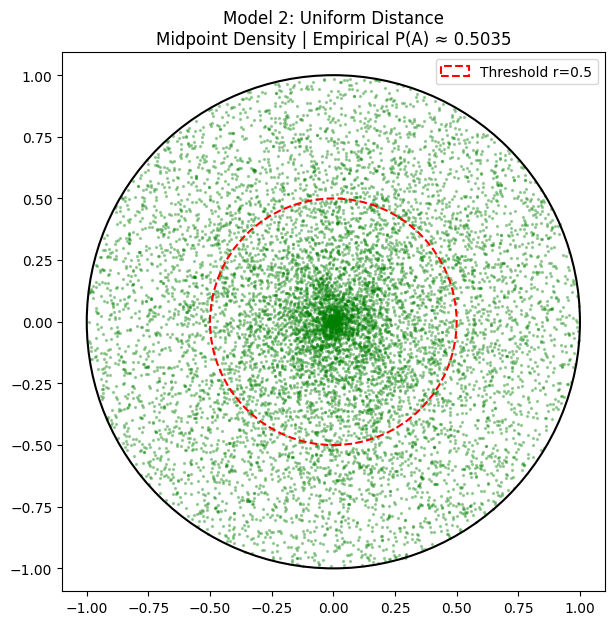

In [5]:
import numpy as np
import matplotlib.pyplot as plt

N_sim = 50000
N_plot = 10000

# Model 2: Choose a uniform distance r, and a uniform angle for the radius
r2 = np.random.uniform(0, 1, N_sim)
phi2 = np.random.uniform(0, 2*np.pi, N_sim)

# Calculate the midpoints
mid_x2 = r2 * np.cos(phi2)
mid_y2 = r2 * np.sin(phi2)

prob2 = np.mean(r2 < 0.5)

# Plotting
plt.figure(figsize=(7, 7))
plt.scatter(mid_x2[:N_plot], mid_y2[:N_plot], s=2, alpha=0.3, color='green')

# Draw the main circle and the threshold circle (r=0.5)
plt.gca().add_patch(plt.Circle((0,0), 1, fill=False, color='black', linewidth=1.5))
plt.gca().add_patch(plt.Circle((0,0), 0.5, fill=False, color='red', linestyle='--', linewidth=1.5, label='Threshold r=0.5'))

plt.title('Model 2: Uniform Distance\nMidpoint Density | Empirical P(A) ≈ {:.4f}'.format(prob2))
plt.axis('equal')
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.legend(loc='upper right')
plt.show()

### Model-3: Random midpoint uniformly in the disk

This model is:

* choose the midpoint of the chord uniformly from the whole disk,
* draw the unique chord having that midpoint.

Since every chord is uniquely determined by its midpoint, this defines a probability law on chords.

---

**Probability space**

Let

$$
\Omega_3=\{(x,y)\in\mathbb R^2:x^2+y^2\le 1\}
$$

be the closed unit disk, with sigma-algebra

$$
\mathfrak A_3=\mathfrak B(\Omega_3).
$$

Define $P_3$ by normalized area:

$$
P_3(E)=\frac{\lambda_2(E)}{\pi},
\qquad E\in\mathfrak A_3,
$$

where $\lambda_2$ is planar Lebesgue measure.

Interpret $(x,y)$ as the midpoint of the chord.

---

**Event**

If the midpoint is $(x,y)$, then its distance from the center is

$$
r=\sqrt{x^2+y^2}.
$$

As shown above, the chord is longer than $\sqrt{3}$ exactly when

$$
r<1/2.
$$

Thus

$$
A_3=\{(x,y)\in\Omega_3:x^2+y^2<1/4\}.
$$

This is the disk of radius (1/2).

---

**Probability**

Therefore

$$
P_3(A_3)=\frac{\text{area of disk of radius }1/2}{\text{area of unit disk}}
=\frac{\pi(1/2)^2}{\pi}
=\frac14.
$$

So under Model 3,

$$
\boxed{P_3(A_3)=\frac14}.
$$


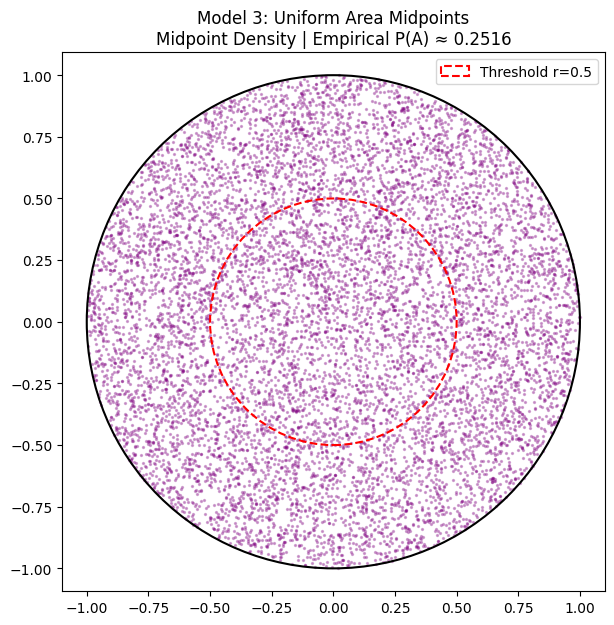

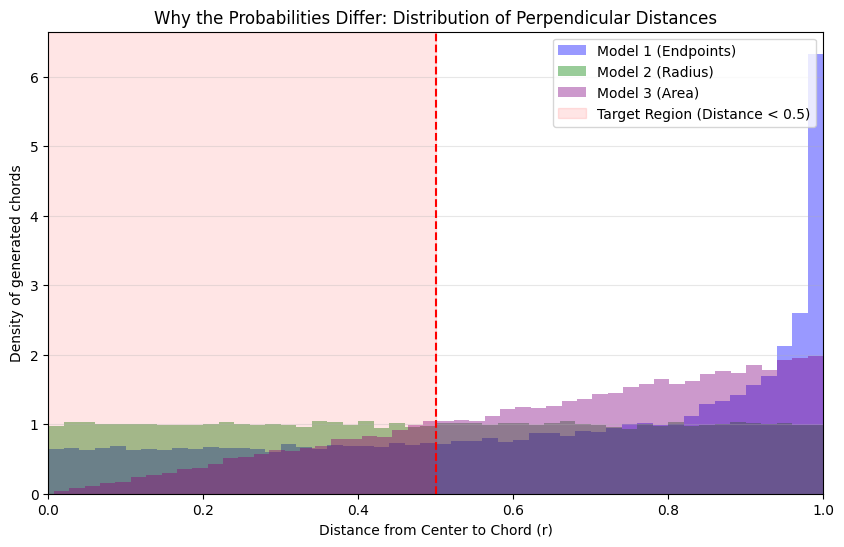

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Regenerate variables to ensure cell runs independently
N_sim = 50000
N_plot = 10000

# Model 3: Uniformly random area requires scaling radius by sqrt of uniform
u = np.random.uniform(0, 1, N_sim)
r3 = np.sqrt(u)
phi3 = np.random.uniform(0, 2*np.pi, N_sim)

mid_x3 = r3 * np.cos(phi3)
mid_y3 = r3 * np.sin(phi3)
prob3 = np.mean(r3 < 0.5)

# --- Plot 1: Model 3 Midpoints ---
plt.figure(figsize=(7, 7))
plt.scatter(mid_x3[:N_plot], mid_y3[:N_plot], s=2, alpha=0.3, color='purple')
plt.gca().add_patch(plt.Circle((0,0), 1, fill=False, color='black', linewidth=1.5))
plt.gca().add_patch(plt.Circle((0,0), 0.5, fill=False, color='red', linestyle='--', linewidth=1.5, label='Threshold r=0.5'))

plt.title('Model 3: Uniform Area Midpoints\nMidpoint Density | Empirical P(A) ≈ {:.4f}'.format(prob3))
plt.axis('equal')
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.legend(loc='upper right')
plt.show()

# --- Plot 2: Histogram Comparison ---
# Recalculate Model 1 & 2 distances just for the histogram in case variables are cleared
t1 = np.random.uniform(0, 2*np.pi, N_sim)
t2 = np.random.uniform(0, 2*np.pi, N_sim)
dist1 = np.sqrt(((np.cos(t1) + np.cos(t2))/2)**2 + ((np.sin(t1) + np.sin(t2))/2)**2)
dist2 = np.random.uniform(0, 1, N_sim)

plt.figure(figsize=(10, 6))
plt.hist(dist1, bins=50, density=True, alpha=0.4, color='blue', label='Model 1 (Endpoints)')
plt.hist(dist2, bins=50, density=True, alpha=0.4, color='green', label='Model 2 (Radius)')
plt.hist(r3, bins=50, density=True, alpha=0.4, color='purple', label='Model 3 (Area)')

plt.axvspan(0, 0.5, color='red', alpha=0.1, label='Target Region (Distance < 0.5)')
plt.axvline(0.5, color='red', linestyle='dashed')

plt.title('Why the Probabilities Differ: Distribution of Perpendicular Distances')
plt.xlabel('Distance from Center to Chord (r)')
plt.ylabel('Density of generated chords')
plt.xlim(0, 1)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### **Conclusion: The Deep Implications of Bertrand's Paradox**

We have arrived at three entirely valid, yet completely different answers ($1/3$, $1/2$, and $1/4$) to what appears to be a simple, single question. This famous problem, known as **Bertrand's Paradox**, is not just a mathematical trick; it highlights fundamental limitations in how we use natural language to describe probability.





**1. The Necessity of Measure Theory**
The paradox demonstrates why modern probability theory requires rigorous definitions of probability spaces (Measure Theory).
* **Model 1** assumes the uniform measure is based on the **arc length** (circumference).
$$
   \frac{\pi-2\pi/3}{\pi}=\frac13.
   $$
* **Model 2** assumes the uniform measure is based on the **linear distance** (radius).
 $$
   \frac12.
   $$

* **Model 3** assumes the uniform measure is based on the **2D area** (the disk).
$$
   \frac{\pi(1/2)^2}{\pi}=\frac14.
   $$

None of these "measures" are mathematically wrong, but they describe entirely different sets of random variables. You cannot calculate the probability of an event without first explicitly defining the underlying geometry of the random generation.


Each answer is correct for a different mathematically precise meaning of “choose a chord at random.”

This is Bertrand's paradox: the verbal description alone does not determine a unique probability model. One must specify the sampling procedure, or equivalently the probability space.








In a certain electricity distribution district, the number of emergency transformer failures reported in a single day is modeled as a discrete random variable $X$. Assume that $X$ takes values in the set $\{0,1,2,3\}$, with probabilities

$$
P(X=0)=0.50,\qquad P(X=1)=0.30,\qquad P(X=2)=0.15,\qquad P(X=3)=0.05.
$$

1. Construct a probability space $(\Omega,\mathfrak F,P)$ suitable for this model.
2. Define $X$ as a random variable on this space.
3. Determine the probability mass function of $X$.
4. Compute the expectation $E[X]$.
5. Compute the variance $\mathrm{Var}(X)$.
6. Find $P(X\ge 1)$ and $P(X\ge 2)$.
7. Briefly explain the practical meaning of the expectation and variance in this setting.



#**Q8) Probability of Being a Girl?**

A family has two children. Assume each child is equally likely to be a boy or a girl, independently of the other.

What is the probability that both children are girls, given that **at least one** of them is a girl?

##**Answer**

sample space:

$$
\Omega=\{BB,BG,GB,GG\},
$$

where the first letter denotes the older child and the second the younger.

Each outcome has probability $1/4$.

Thepossible outcomes for condition  “at least one is a girl” ;

$$
\{GG,BG,GB\}.
$$

Among these three equally likely outcomes, only one is $GG$. Therefore

$$
P(\text{both girls}\mid \text{at least one girl})=\frac{1}{3}.
$$

So the answer is

$$
\boxed{\frac13}.
$$



# **Q9) Information Available in a Discrete Random Variable**

A factory inspects a product and records its quality using two different coding systems.

Each product falls into exactly one of the following four categories:

* $G_1$: good quality, produced on Machine 1
* $G_2$: good quality, produced on Machine 2
* $D_1$: defective, produced on Machine 1
* $D_2$: defective, produced on Machine 2

Assume the sample space is

$$
\Omega=\{G_1,G_2,D_1,D_2\},
$$

with probabilities

$$
P(\{G_1\})=0.50,\qquad P(\{G_2\})=0.20,\qquad P(\{D_1\})=0.10,\qquad P(\{D_2\})=0.20.
$$

Define two discrete random variables on the same probability space:

* $X$ records only whether the item is good or defective:
  $$
  X(G_1)=0,\quad X(G_2)=0,\quad X(D_1)=1,\quad X(D_2)=1.
  $$

* $Y$ records both quality and machine:
  $$
  Y(G_1)=1,\quad Y(G_2)=2,\quad Y(D_1)=3,\quad Y(D_2)=4.
  $$

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$, where $\mathfrak F=\mathfrak P(\Omega)$.

2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

4. Show that $\sigma(X)\subseteq \sigma(Y)$, and explain why $Y$ contains more information than $X$.

5. Find the marginal distribution of $X$.

6. Find the marginal distribution of $Y$.

7. Compute the joint probabilities
   $$
   P(X=0,Y=1),\quad P(X=0,Y=2),\quad P(X=1,Y=3),\quad P(X=1,Y=4).
   $$

8. Compute the conditional probabilities
   $$
   P(X=1\mid Y=3),\qquad P(X=1\mid Y=4),\qquad P(Y=3\mid X=1),\qquad P(Y=4\mid X=1).
   $$

9. Interpret the difference between conditioning on $X$ and conditioning on $Y$.

10. Explain, in words, what information is available in $\sigma(X)$ but not in $\sigma(Y)$, and what information is available in $\sigma(Y)$ but not in $\sigma(X)$.

11. Give a Python based visualization of the model.

12. Find the marginal, joint, and conditional Shannon Entropy of $X$ and $Y$.

##**Answer**

### 1. Probability Space $(\Omega, \mathfrak{F}, P)$
To formally define the probability space:
* **Sample Space ($\Omega$):** The set of all fundamental outcomes.
  $$\Omega = \{G_1, G_2, D_1, D_2\}$$
* **Sigma-Algebra ($\mathfrak{F}$):** Since it is a finite sample space and $\mathfrak{F} = \mathfrak{P}(\Omega)$, the sigma-algebra is the power set (the collection of all $2^4 = 16$ possible subsets of $\Omega$).
* **Probability Measure ($P$):** Defined by the sum of the probabilities of the singletons in any event $A \in \mathfrak{F}$:
  $$P(\{G_1\}) = 0.50, \quad P(\{G_2\}) = 0.20, \quad P(\{D_1\}) = 0.10, \quad P(\{D_2\}) = 0.20$$

---

### 2. $\sigma$-algebra generated by $X$, $\sigma(X)$
The sigma-algebra generated by a random variable contains the pre-images of all possible sets of its values. Since $X$ only maps to $\{0, 1\}$, we look at the subsets of $\Omega$ that correspond to $X=0$ and $X=1$:
* $X=0$ corresponds to $\{G_1, G_2\}$
* $X=1$ corresponds to $\{D_1, D_2\}$

Including the empty set and the full sample space to satisfy the definition of a sigma-algebra gives:
$$\sigma(X) = \{\emptyset, \{G_1, G_2\}, \{D_1, D_2\}, \Omega\}$$

---

### 3. $\sigma$-algebra generated by $Y$, $\sigma(Y)$
$Y$ maps every single outcome in $\Omega$ to a unique, distinct value ($1, 2, 3, 4$). Therefore, the pre-images of $Y$ can isolate every individual singleton in the sample space: $\{G_1\}$, $\{G_2\}$, $\{D_1\}$, and $\{D_2\}$.
Any sigma-algebra containing all singletons of a finite space must contain all possible combinations of those singletons. Thus, it generates the full power set:
$$\sigma(Y) = \mathfrak{P}(\Omega) = \mathfrak{F}$$

---

### 4. Show $\sigma(X) \subseteq \sigma(Y)$ and explain information
* **Proof:** As found above, $\sigma(X)$ contains exactly 4 sets. $\sigma(Y)$ is the power set, meaning it contains *all* 16 possible subsets of $\Omega$. Therefore, every set in $\sigma(X)$ is guaranteed to be in $\sigma(Y)$. Hence, $\sigma(X) \subseteq \sigma(Y)$.
* **Explanation:** $Y$ contains more information because knowing the value of $Y$ tells you exactly which fundamental outcome occurred (e.g., if $Y=1$, you know the item is $G_1$). Once you know the exact outcome, you automatically know the value of $X$ ($0$ in this case). However, the reverse is not true. $X$ only tells you the quality, grouping the machines together. It is a "coarser" partition of the data.

---

### 5. Marginal distribution of $X$
We sum the probabilities of the outcomes associated with each value of $X$:
* $P(X=0) = P(\{G_1, G_2\}) = 0.50 + 0.20 = 0.70$
* $P(X=1) = P(\{D_1, D_2\}) = 0.10 + 0.20 = 0.30$

---

### 6. Marginal distribution of $Y$
Since $Y$ assigns a unique value to each outcome, its marginal distribution is identical to the probability measure of the singletons:
* $P(Y=1) = P(\{G_1\}) = 0.50$
* $P(Y=2) = P(\{G_2\}) = 0.20$
* $P(Y=3) = P(\{D_1\}) = 0.10$
* $P(Y=4) = P(\{D_2\}) = 0.20$

---

### 7. Compute the Joint Probabilities
The joint probability $P(X=x, Y=y)$ is the probability of the intersection of the two events. Because $Y$ completely determines $X$, many intersections are empty. The non-zero joint probabilities simply map back to the singletons:
* $P(X=0, Y=1) = P(\{G_1, G_2\} \cap \{G_1\}) = P(\{G_1\}) = 0.50$
* $P(X=0, Y=2) = P(\{G_1, G_2\} \cap \{G_2\}) = P(\{G_2\}) = 0.20$
* $P(X=1, Y=3) = P(\{D_1, D_2\} \cap \{D_1\}) = P(\{D_1\}) = 0.10$
* $P(X=1, Y=4) = P(\{D_1, D_2\} \cap \{D_2\}) = P(\{D_2\}) = 0.20$

---

### 8. Compute the Conditional Probabilities
Using the formula $P(A|B) = P(A \cap B) / P(B)$:
* $P(X=1 | Y=3) = \frac{0.10}{0.10} = 1$
* $P(X=1 | Y=4) = \frac{0.20}{0.20} = 1$
* $P(Y=3 | X=1) = \frac{P(X=1, Y=3)}{P(X=1)} = \frac{0.10}{0.30} = \frac{1}{3} \approx 0.333$
* $P(Y=4 | X=1) = \frac{P(X=1, Y=4)}{P(X=1)} = \frac{0.20}{0.30} = \frac{2}{3} \approx 0.667$

---

### 9. Interpret the difference between conditioning on $X$ and $Y$

Conditioning on $Y$ gives more precise information than conditioning on $X$. If we know $Y = 3$, then we know with certainty that the item is defective, so
$$P(X = 1 \mid Y = 3) = 1.$$
But if we know only that $X = 1$, we know the item is defective but we do not know which machine produced it. Then there is still uncertainty:
$$P(Y = 3 \mid X = 1) = \frac{1}{3}, \quad P(Y = 4 \mid X = 1) = \frac{2}{3}.$$

---

### 10. Information available in $\sigma(X)$ vs $\sigma(Y)$

The $\sigma$-algebra $\sigma(X)$ contains only the information about quality class:
* whether the item is good,
* or whether it is defective.

It does not distinguish between Machine 1 and Machine 2.

By contrast, $\sigma(Y)$ contains full information about the outcome. It tells us both whether the item is good or defective and which machine produced it. Thus $\sigma(Y)$ is strictly finer than $\sigma(X)$.

A concise conclusion is:
> The two random variables are defined on the same sample space, but they generate different $\sigma$-algebras. Since
> $$\sigma(X) \subseteq \sigma(Y),$$
> the variable $Y$ carries more information than $X$. This is reflected in the conditional probabilities: conditioning on $Y$ can remove uncertainty that remains when conditioning only on $X$.

---

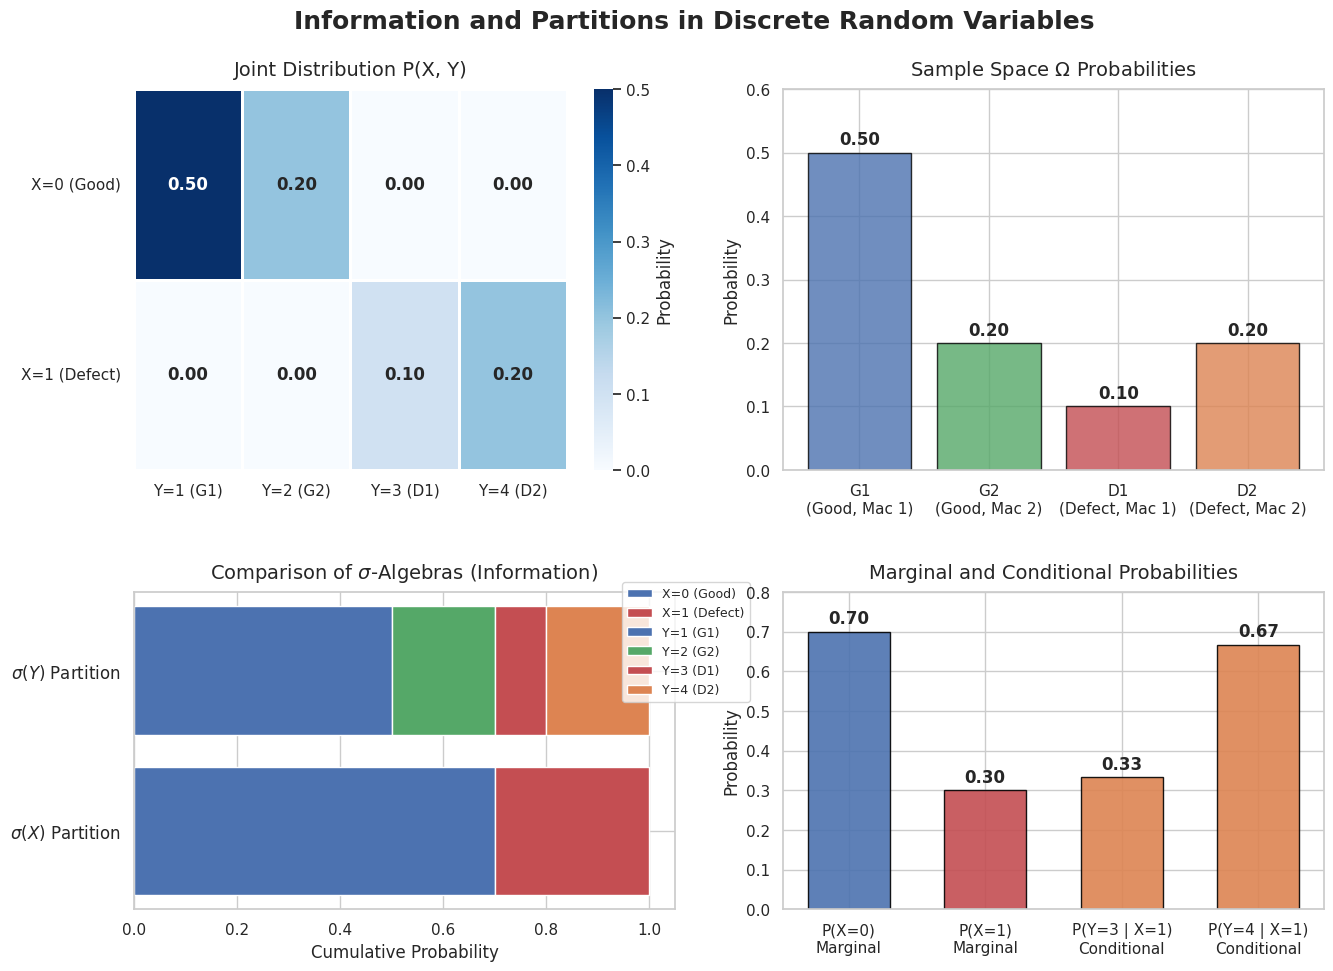

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set seaborn theme for professional aesthetics
sns.set_theme(style="whitegrid", palette="muted")

# --- Data Definitions ---
omega = ["G1\n(Good, Mac 1)", "G2\n(Good, Mac 2)", "D1\n(Defect, Mac 1)", "D2\n(Defect, Mac 2)"]
p = np.array([0.50, 0.20, 0.10, 0.20])

# Marginals
px = {0: p[0] + p[1], 1: p[2] + p[3]}
py = {1: p[0], 2: p[1], 3: p[2], 4: p[3]}

# Joint Distribution P(X, Y)
joint = np.array([
    [0.50, 0.20, 0.00, 0.00],  # X = 0 (Good)
    [0.00, 0.00, 0.10, 0.20]   # X = 1 (Defective)
])

# Conditionals
p_y3_given_x1 = p[2] / (p[2] + p[3])
p_y4_given_x1 = p[3] / (p[2] + p[3])

# --- Create Dashboard Layout ---
fig = plt.figure(figsize=(14, 10))
fig.suptitle("Information and Partitions in Discrete Random Variables", fontsize=18, fontweight='bold')

# Define grid
gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1], wspace=0.2, hspace=0.35)

# --- 1. Joint Distribution Heatmap (Top Left) ---
ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(joint, annot=True, cmap="Blues", fmt=".2f", cbar_kws={'label': 'Probability'}, ax=ax1,
            linewidths=1, linecolor='white', annot_kws={"size": 12, "weight": "bold"})
ax1.set_xticks(np.arange(4) + 0.5)
ax1.set_xticklabels(['Y=1 (G1)', 'Y=2 (G2)', 'Y=3 (D1)', 'Y=4 (D2)'])
ax1.set_yticks(np.arange(2) + 0.5)
ax1.set_yticklabels(['X=0 (Good)', 'X=1 (Defect)'], rotation=0)
ax1.set_title("Joint Distribution P(X, Y)", fontsize=14, pad=10)

# --- 2. Sample Space & Marginals (Top Right) ---
ax2 = fig.add_subplot(gs[0, 1])
colors = ["#4C72B0", "#55A868", "#C44E52", "#DD8452"]  # Blue, Green, Red, Orange
bars = ax2.bar(omega, p, color=colors, edgecolor="black", alpha=0.8)

ax2.set_title(r"Sample Space $\Omega$ Probabilities", fontsize=14, pad=10)
ax2.set_ylabel("Probability")
ax2.set_ylim(0, 0.6)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax2.annotate(f'{height:.2f}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points",
                 ha='center', va='bottom', fontweight='bold')

# --- 3. Partitions & Information (Bottom Left) ---
ax3 = fig.add_subplot(gs[1, 0])
y_pos = [1, 0]

# X Partition
ax3.barh(y_pos[1], px[0], color="#4C72B0", edgecolor="white", label="X=0 (Good)")
ax3.barh(y_pos[1], px[1], left=px[0], color="#C44E52", edgecolor="white", label="X=1 (Defect)")

# Y Partition
ax3.barh(y_pos[0], py[1], color="#4C72B0", edgecolor="white", label="Y=1 (G1)")
ax3.barh(y_pos[0], py[2], left=py[1], color="#55A868", edgecolor="white", label="Y=2 (G2)")
ax3.barh(y_pos[0], py[3], left=py[1]+py[2], color="#C44E52", edgecolor="white", label="Y=3 (D1)")
ax3.barh(y_pos[0], py[4], left=py[1]+py[2]+py[3], color="#DD8452", edgecolor="white", label="Y=4 (D2)")

ax3.set_yticks(y_pos)
ax3.set_yticklabels([r'$\sigma(Y)$ Partition', r'$\sigma(X)$ Partition'], fontsize=12)
ax3.set_xlabel("Cumulative Probability")

ax3.set_title(r"Comparison of $\sigma$-Algebras (Information)", fontsize=14, pad=10)
ax3.legend(loc='upper right', bbox_to_anchor=(1.15, 1.05), fontsize=9)

# --- 4. Conditionals (Bottom Right) - UPDATED TO MATCH USER REFERENCE ---
ax4 = fig.add_subplot(gs[1, 1])

# Added P(X=0) and adjusted labels
cond_labels = ["P(X=0)\nMarginal", "P(X=1)\nMarginal", "P(Y=3 | X=1)\nConditional", "P(Y=4 | X=1)\nConditional"]
cond_vals = [px[0], px[1], p_y3_given_x1, p_y4_given_x1]

# Colors: Blue (X=0), Red (X=1), Orange (Y|X) to match the dashboard's palette and your reference
cond_colors = ["#4C72B0", "#C44E52", "#DD8452", "#DD8452"]

bars4 = ax4.bar(cond_labels, cond_vals, color=cond_colors, edgecolor="black", width=0.6, alpha=0.9)
ax4.set_title("Marginal and Conditional Probabilities", fontsize=14, pad=10)
ax4.set_ylabel("Probability")
ax4.set_ylim(0, 0.8) # Increased to fit 0.70 comfortably

# Add value labels
for bar in bars4:
    height = bar.get_height()
    ax4.annotate(f'{height:.2f}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points",
                 ha='center', va='bottom', fontweight='bold')

# Use subplots_adjust to prevent GridSpec warnings
fig.subplots_adjust(top=0.90, bottom=0.08, left=0.10, right=0.95)
plt.show()

### 12. Entropies

Using natural logarithms, the Shannon entropy is
$$H(Z) = -\sum_z P(z) \ln P(z).$$
so
$$H(X) = -(0.70 \ln 0.70 + 0.30 \ln 0.30),$$
$$H(Y) = -(0.50 \ln 0.50 + 0.20 \ln 0.20 + 0.10 \ln 0.10 + 0.20 \ln 0.20).$$
Thus
$$H(X) \approx 0.61086,$$
and
$$H(Y) \approx 1.22061.$$

For the joint entropy,
$$H(X, Y) = -\sum_{x,y} P(x, y) \ln P(x, y),$$
so only the nonzero terms contribute:
$$H(X, Y) = -(0.50 \ln 0.50 + 0.20 \ln 0.20 + 0.10 \ln 0.10 + 0.20 \ln 0.20).$$
Therefore
$$H(X, Y) \approx 1.22061.$$

Since each value of $Y$ determines $X$ exactly,
$$H(X \mid Y) = 0.$$
Also,
$$H(Y \mid X) = H(X, Y) - H(X),$$
so
$$H(Y \mid X) \approx 1.22061 - 0.61086 = 0.60975.$$

So in natural logarithm form:
$$H(X) \approx 0.61086$$
$$H(Y) \approx 1.22061$$
$$H(X, Y) \approx 1.22061$$
$$H(X \mid Y) = 0$$
$$H(Y \mid X) \approx 0.60975$$

**A useful interpretation is:**
* $H(X)$ measures uncertainty about whether an item is good or defective,
* $H(Y)$ measures uncertainty about the full category,
* $H(X \mid Y) = 0$ because knowing $Y$ tells us $X$ exactly,
* $H(Y \mid X) > 0$ because knowing only $X$ does not tell us which machine produced the item.

So this entropy calculation gives another precise way to say that $Y$ contains more information than $X$.

# **Q10) Information Available in Continuous Random Varaibles**

A chemical plant monitors each production run using two different measurement systems.

For a given run, let

* $T$ be the deviation of the reactor temperature from target, measured in standardized units,
* $P$ be the deviation of the reactor pressure from target, also measured in standardized units.

Assume that $(T,P)$ is jointly continuous, with independent normal components:

$$
T \sim N(0,1), \qquad P \sim N(0,4),
$$

and $T$ and $P$ are independent.

Let the underlying probability space be

$$
\Omega=\mathbb R^2, \qquad \mathfrak F=\mathfrak B(\mathbb R^2),
$$

and let $P$ be the probability measure induced by the joint density

$$
f_{T,P}(t,p)=\frac{1}{4\pi}\exp\left(-\frac{t^2}{2}-\frac{p^2}{8}\right), \qquad (t,p)\in\mathbb R^2.
$$

Define two random variables on the same probability space:

* $X:\Omega\to\mathbb R$ by
  $$
  X(t,p)=t,
  $$
  so that $X$ records only the reactor temperature deviation;

* $Y:\Omega\to\mathbb R^2$ by
  $$
  Y(t,p)=(t,p),
  $$
  so that $Y$ records the full sensor state: both temperature and pressure deviations.

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$ explicitly.

2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

4. Show that
   $$
   \sigma(X)\subseteq \sigma(Y),
   $$
   and explain why $Y$ contains more information than $X$.

5. Find the marginal density of $X$.

6. Find the marginal density of $Y$.

7. Compute the following probabilities:
   $$
   P(X\leq 0), \qquad P(X>1), \qquad P(Y\in (-\infty,0]\times\mathbb R), \qquad P(Y\in [ -1,1]\times[-2,2]).
   $$

8. Compute the conditional distribution of $X$ given $Y=(t,p)$.

9. Compute the conditional distribution of $Y$ given $X=t$.

10. Explain, in words, what is known when one conditions on $X$ and what additional information becomes available when one conditions on $Y$.

11. Show that
    $$
    X=\pi_1\circ Y,
    $$
    where $\pi_1(t,p)=t$, and explain why this implies that $X$ is a measurable function of $Y$.

12. Give a Python-based visualization of the model, for example by plotting:

* the joint density of $Y=(T,P)$ as a contour plot or heat map;
* the marginal density of $X$;
* and a diagram illustrating that $\sigma(X)$ is coarser than $\sigma(Y)$.

13. Compute the differential entropy of $X$:

$$
h(X)=-\int_{\mathbb R} f_X(x)\ln f_X(x)\,dx.
$$

14. Compute the differential entropy of $Y$:

$$
h(Y)=-\int_{\mathbb R^2} f_Y(t,p)\ln f_Y(t,p)\,dt\,dp.
$$

15. Compute the conditional differential entropy

$$
h(Y|X),
$$

and interpret it physically.

16. Discuss what happens to

$$
h(X|Y)
$$

in this model, and explain why the continuous case differs from the discrete case when one random variable is completely determined by the other.


##**Answer**

### 1. The Probability Space

To formally define the probability space:

$$(\Omega, \mathfrak{F}, P)$$

* **Sample Space:** The set of all possible outcomes for temperature and pressure deviations.

$$\Omega = \mathbb{R}^2$$

* **Sigma-Algebra:** The Borel sigma-algebra on the 2D plane, which contains all measurable subsets (areas).

$$\mathfrak{F} = \mathfrak{B}(\mathbb{R}^2)$$

* **Probability Measure:** For any set:

$$A \in \mathfrak{F}$$

the probability is the volume under the joint density function over the region:

$$P(A) = \iint_A \frac{1}{4\pi} \exp\left(-\frac{t^2}{2} - \frac{p^2}{8}\right) \,dt \,dp$$

---

### 2. Sigma-algebra generated by X

The random variable:

$$X(t,p) = t$$

only records the first coordinate. Its generated sigma-algebra consists of the pre-images of Borel sets:

$$B \in \mathfrak{B}(\mathbb{R})$$

Geometrically, these are vertical strips in the plane.

$$\sigma(X) = \{ B \times \mathbb{R} : B \in \mathfrak{B}(\mathbb{R}) \}$$

---

### 3. Sigma-algebra generated by Y


  $$
  Y(t,p)=(t,p).
  $$

  Thus $Y$ records both temperature and pressure.

  Since $Y$ is the identity map on $\mathbb R^2$, its generated $\sigma$-algebra is

  $$
  \sigma(Y)=\mathfrak B(\mathbb R^2).
  $$

  Indeed, for every Borel set $A\subseteq\mathbb R^2$,

  $$
  Y^{-1}(A)=A.
  $$

  Hence

  $$
  \sigma(Y)=\mathfrak B(\mathbb R^2).
  $$


---

### 4. Show that the X sigma-algebra is a subset of the Y sigma-algebra

**Proof:** Any set in the X sigma-algebra takes the form:

$$B \times \mathbb{R}$$

Because the first part is a 1D Borel set and the set of all real numbers is trivially a Borel set, their Cartesian product is guaranteed to be a 2D Borel set. Therefore, every set generated by X is also in the 2D Borel sigma-algebra, which is generated by Y.

$$\sigma(X) \subseteq \sigma(Y)$$

**Explanation:** The variable Y contains more information because it can pinpoint exact coordinates. The variable X is "blind" to the pressure. If you only know X, you only know which vertical strip the outcome falls into, but you have no information about where it lies vertically within that strip.

---

### 5. Marginal density of X

$$
f_X(x)=\int_{-\infty}^{\infty} f_{T,P}(x,p)dp.
$$

So

$$
f_X(x)=\int_{-\infty}^{\infty}\frac{1}{4\pi}\exp\left(-\frac{x^2}{2}-\frac{p^2}{8}\right)dp.
$$

Since

$$
\int_{-\infty}^{\infty}\frac{1}{\sqrt{8\pi}}\exp\left(-\frac{p^2}{8}\right)dp=1,
$$

this simplifies to

$$
f_X(x)=\frac{1}{\sqrt{2\pi}}\exp\left(-\frac{x^2}{2}\right).
$$

Thus

$$
X\sim N(0,1).
$$

---

### 6. Marginal density of Y

The variable Y represents the joint state of temperature and pressure. Since they are independent, the marginal density of Y is simply the joint density provided in the problem.

$$f_Y(t,p) = \frac{1}{4\pi} \exp\left(-\frac{t^2}{2} - \frac{p^2}{8}\right)$$

---

### 7. Compute Probabilities

**Probability that X is less than or equal to 0:**
Due to the symmetry of the standard normal distribution:

$$P(X \le 0) = 0.50$$

**Probability that X is greater than 1:**
Using the standard normal cumulative distribution function:

$$P(X > 1) = 1 - \Phi(1) \approx 0.1587$$

**Probability of Y for negative temperature and any pressure:**
This is the probability that the temperature is less than or equal to 0, and the pressure is anything. It is equivalent to the first probability above.

$$P(Y \in (-\infty, 0] \times \mathbb{R}) = 0.50$$

**Probability of Y in the specified rectangular region:**
Because temperature and pressure are independent, we multiply their separate probabilities. The pressure distribution means its standard deviation is 2.

$$P(-1 \le T \le 1) \cdot P(-2 \le P \le 2)$$

Since both intervals represent exactly plus or minus 1 standard deviation from their respective means:

$$\approx (0.6827) \cdot (0.6827) \approx 0.466$$

---

### 8. Conditional distribution of X given Y

If you are given exact values for Y:

$$Y = (t,p)$$

you know the exact temperature and pressure. Therefore, X (which is just the temperature) is known with absolute certainty to be exactly that temperature value.

The conditional distribution is a deterministic point mass (Dirac delta) at that temperature.

$$f_{X|Y}(x \mid t,p) = \delta(x - t)$$

---

### 9. Conditional distribution of Y given X

If you are given an exact value for X:

$$X = t$$

you know the temperature. Because temperature and pressure are independent, knowing the temperature gives you zero new information about the pressure. Therefore, the pressure retains its original marginal distribution.

The conditional distribution is a "slice" where temperature is fixed, and pressure is normally distributed.

$$f_{Y|X}(t', p' \mid t) = \delta(t' - t) \cdot \frac{1}{\sqrt{8\pi}} \exp\left(-\frac{p'^2}{8}\right)$$

---

### 10. Information known under conditioning

**Conditioning on X:** We know the exact horizontal position (temperature) in the reactor, but the vertical position (pressure) remains completely uncertain and normally distributed.

**Conditioning on Y:** We gain the additional information of the exact pressure. All uncertainty is removed, and we know the exact point state of the reactor.

---

### 11. Show that X is a measurable function of Y

$$
\pi_1:\mathbb R^2\to\mathbb R, \qquad \pi_1(t,p)=t.
$$

Then

$$
X=\pi_1\circ Y.
$$

Indeed,

$$
(\pi_1\circ Y)(t,p)=\pi_1(t,p)=t=X(t,p).
$$

Since $\pi_1$ is Borel measurable and $X$ is a measurable function of $Y$, it follows that

$$
\sigma(X)\subseteq \sigma(Y).
$$

This gives a direct measurable explanation for why $Y$ is more informative than $X$.

---


### 13. Differential entropy of X

For a normal distribution with variance 1, the differential entropy is:

$$h(X) = \frac{1}{2} \ln(2\pi e) \approx 1.4189 $$

---

### 14. Differential entropy of Y

$$
h(Y)=h(T)+h(P).
$$

Now

$$
h(T)=\frac{1}{2}\ln(2\pi e),
$$

and

$$
h(P)=\frac{1}{2}\ln(2\pi e\cdot 4).
$$
Therefore

$$
h(Y)=\frac{1}{2}\ln(2\pi e)+\frac{1}{2}\ln(8\pi e).
$$

Equivalently,

$$
h(Y)=\frac{1}{2}\ln\bigl((2\pi e)^2\cdot 4\bigr)
=\ln(2\pi e)+\ln 2.
$$
Numerically,

$$
h(Y)\approx 3.5310.
$$

---


### 15. Conditional differential entropy

Using the chain rule for differential entropy:

$$h(Y|X) = h(X, Y) - h(X)$$

Since Y already contains X, the joint entropy is equal to the entropy of Y.

$$h(Y|X) = \ln(4\pi e) - \frac{1}{2} \ln(2\pi e) = \frac{1}{2} \ln(8\pi e) \approx 2.1121 $$

**Physical Interpretation:**
Because temperature and pressure are independent, knowing the temperature removes exactly the entropy associated with the temperature. The remaining uncertainty is simply the entropy of the pressure alone.

---

### 16. Discuss what happens to the conditional entropy of X given Y

If Y is known exactly, then X is determined with absolute certainty. One might initially guess that:

$$h(X|Y) = 0$$

However, for differential entropy, this is not the correct conclusion. In the continuous setting, the conditional law of X given Y is degenerate, meaning the conditional differential entropy is not an ordinary finite quantity. In fact, it is best understood as formally tending to:

$$-\infty$$

This highlights one of the major differences between discrete entropy and differential entropy.

In the **discrete case**, if X is exactly determined by Y, then:

$$H(X|Y) = 0$$

In the **continuous case**, exact deterministic dependence corresponds to a singular conditional distribution, and differential entropy behaves differently.

**Thus, this example shows:**

* The generated sigma-algebras satisfy:

$$\sigma(X) \subseteq \sigma(Y)$$

* Y contains more information than X.

* The conditional entropy $h(Y|X)$ is a meaningful positive quantity.

* The conditional entropy $h(X|Y)$ is not analogous to the discrete case and reflects the subtleties of continuous entropy.

---

**Conclusion:**

The variables X and Y are defined on the same probability space, but X is a coarser observation while Y is a finer one. This is reflected in the inclusion:

$$\sigma(X) \subseteq \sigma(Y)$$

It is also reflected in the fact that X is a measurable function of Y, and in the entropy calculations: knowing X leaves uncertainty about Y, but knowing Y completely determines X.

## **Python Visualization**

### **Visualizing the $\sigma$-Algebras (Partitions)**

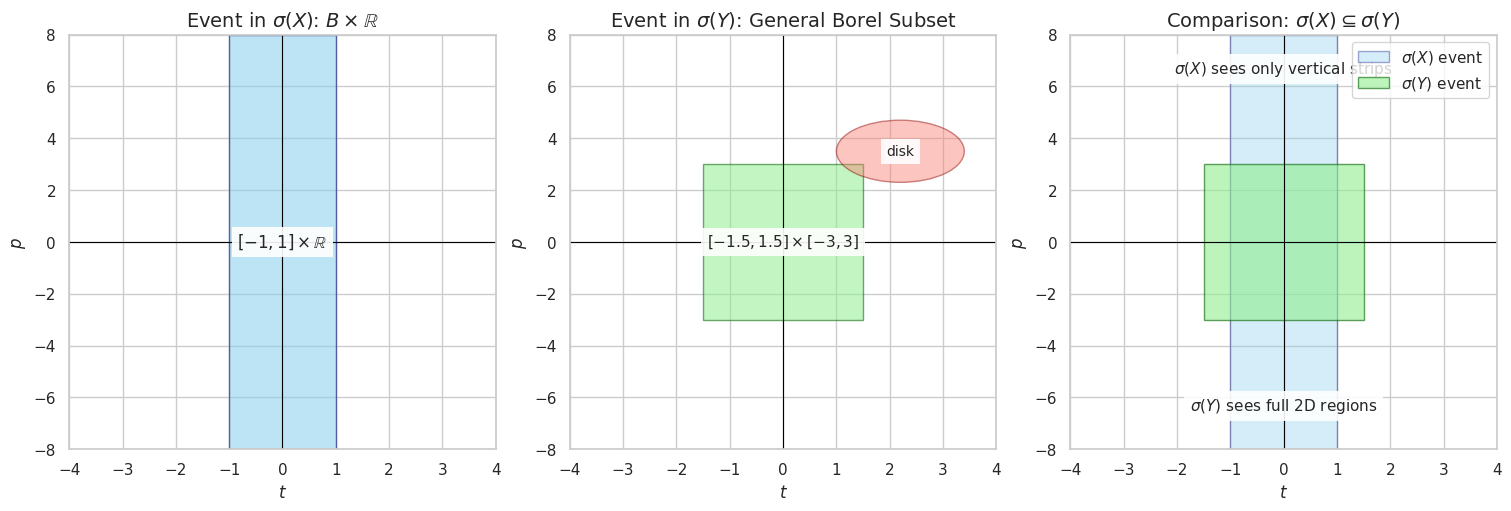

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
import seaborn as sns

# Set seaborn theme for professional aesthetics
sns.set_theme(style="whitegrid", palette="muted")

fig = plt.figure(figsize=(15, 5), constrained_layout=True)
axes = fig.subplots(1, 3)

xlim = (-4, 4)
ylim = (-8, 8)

# -------------------------
# (1) Event in sigma(X)
# -------------------------
ax = axes[0]
ax.set_title(r"Event in $\sigma(X)$: $B\times\mathbb{R}$", fontsize=14)
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_xlabel(r"$t$"); ax.set_ylabel(r"$p$")

# Example B = [-1,1]
strip = Rectangle((-1, ylim[0]), 2, ylim[1] - ylim[0],
                  facecolor="skyblue", edgecolor="navy", alpha=0.55)
ax.add_patch(strip)

ax.text(0, 0, r"$[-1,1]\times \mathbb{R}$",
        ha="center", va="center", fontsize=12,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.9))

ax.axhline(0, color="black", lw=0.8); ax.axvline(0, color="black", lw=0.8)

# -------------------------
# (2) Event in sigma(Y)
# -------------------------
ax = axes[1]
ax.set_title(r"Event in $\sigma(Y)$: General Borel Subset", fontsize=14)
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_xlabel(r"$t$"); ax.set_ylabel(r"$p$")

# Example rectangle in sigma(Y)
rect = Rectangle((-1.5, -3), 3, 6,
                 facecolor="lightgreen", edgecolor="darkgreen", alpha=0.55)
ax.add_patch(rect)

# Also add a disk to emphasize generality
disk = Circle((2.2, 3.5), 1.2,
              facecolor="salmon", edgecolor="darkred", alpha=0.45)
ax.add_patch(disk)

ax.text(0, 0, r"$[-1.5,1.5]\times[-3,3]$",
        ha="center", va="center", fontsize=11,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.9))
ax.text(2.2, 3.5, r"disk",
        ha="center", va="center", fontsize=10,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.9))

ax.axhline(0, color="black", lw=0.8); ax.axvline(0, color="black", lw=0.8)

# -------------------------
# (3) Comparison
# -------------------------
ax = axes[2]
ax.set_title(r"Comparison: $\sigma(X) \subseteq \sigma(Y)$", fontsize=14)
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_xlabel(r"$t$"); ax.set_ylabel(r"$p$")

# Vertical strip for sigma(X)
strip2 = Rectangle((-1, ylim[0]), 2, ylim[1] - ylim[0],
                   facecolor="skyblue", edgecolor="navy", alpha=0.35,
                   label=r"$\sigma(X)$ event")
ax.add_patch(strip2)

# Rectangle for sigma(Y)
rect2 = Rectangle((-1.5, -3), 3, 6,
                  facecolor="lightgreen", edgecolor="darkgreen", alpha=0.6,
                  label=r"$\sigma(Y)$ event")
ax.add_patch(rect2)

ax.text(0, 6.5, r"$\sigma(X)$ sees only vertical strips",
        ha="center", fontsize=11,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.9))
ax.text(0, -6.5, r"$\sigma(Y)$ sees full 2D regions",
        ha="center", fontsize=11,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.9))

ax.axhline(0, color="black", lw=0.8); ax.axvline(0, color="black", lw=0.8)
ax.legend(loc="upper right")

plt.show()

###**Visualizing the Continuous Densities**

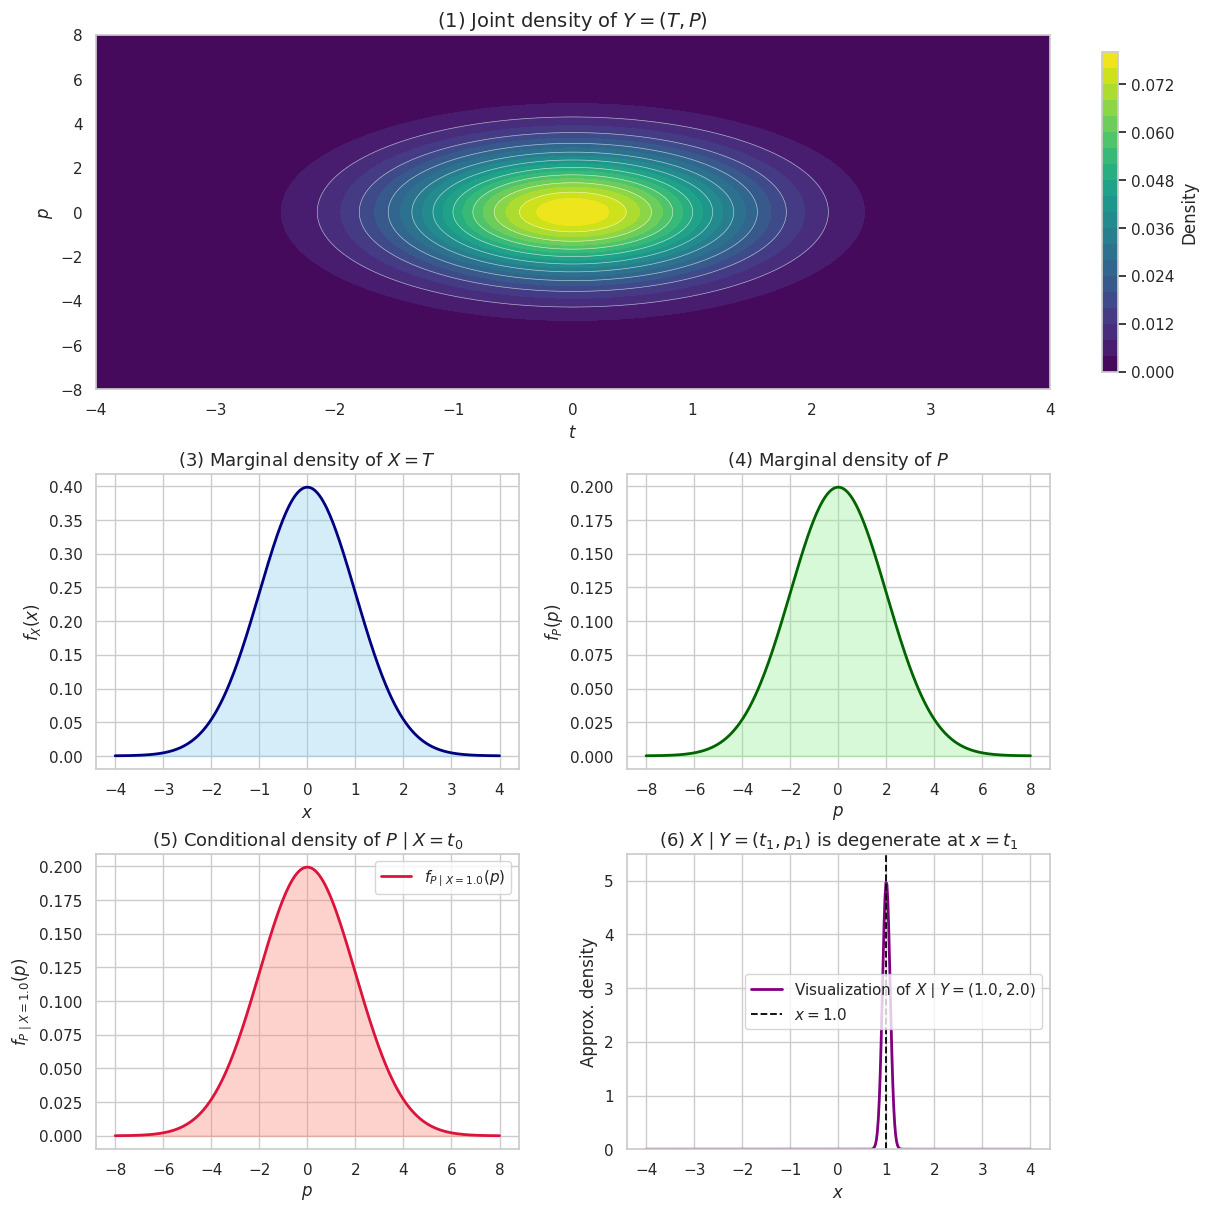

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

# Set seaborn theme for professional aesthetics
sns.set_theme(style="whitegrid", palette="muted")

# Parameters
mu_T, sigma_T = 0.0, 1.0
mu_P, sigma_P = 0.0, 2.0   # since Var(P)=4

# Grids
t = np.linspace(-4, 4, 400)
p = np.linspace(-8, 8, 400)
T, P = np.meshgrid(t, p)

# Joint density of Y = (T, P)
joint_pdf = (
    norm.pdf(T, loc=mu_T, scale=sigma_T) *
    norm.pdf(P, loc=mu_P, scale=sigma_P)
)

# Marginal density of X = T
fx = norm.pdf(t, loc=mu_T, scale=sigma_T)

# Conditional density of P | X=t0
# Independence implies P | X=t0 ~ N(0,4)
t0 = 1.0
cond_p_given_x = norm.pdf(p, loc=mu_P, scale=sigma_P)

# Conditional distribution of X | Y=(t1,p1):
# Degenerate at t1, approximated here by a narrow Gaussian just for visualization
t1, p1 = 1.0, 2.0
eps = 0.08
cond_x_given_y_vis = norm.pdf(t, loc=t1, scale=eps)

# Figure with subplot layout using constrained_layout
fig = plt.figure(figsize=(12, 12), constrained_layout=True)
gs = fig.add_gridspec(3, 2, height_ratios=[1.2, 1, 1])

# (1) Joint contour spanning full top row
ax1 = fig.add_subplot(gs[0, :])
cs = ax1.contourf(T, P, joint_pdf, levels=25, cmap="viridis")
ax1.contour(T, P, joint_pdf, levels=10, colors="white", linewidths=0.5, alpha=0.6)
ax1.set_title(r"(1) Joint density of $Y=(T,P)$", fontsize=14)
ax1.set_xlabel(r"$t$")
ax1.set_ylabel(r"$p$")
fig.colorbar(cs, ax=ax1, shrink=0.9, label="Density")

# (3) Marginal of X
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(t, fx, color="navy", lw=2)
ax3.fill_between(t, fx, color="skyblue", alpha=0.35)
ax3.set_title(r"(3) Marginal density of $X=T$", fontsize=13)
ax3.set_xlabel(r"$x$")
ax3.set_ylabel(r"$f_X(x)$")

# (4) Marginal of P
ax4 = fig.add_subplot(gs[1, 1])
fp = norm.pdf(p, loc=mu_P, scale=sigma_P)
ax4.plot(p, fp, color="darkgreen", lw=2)
ax4.fill_between(p, fp, color="lightgreen", alpha=0.35)
ax4.set_title(r"(4) Marginal density of $P$", fontsize=13)
ax4.set_xlabel(r"$p$")
ax4.set_ylabel(r"$f_P(p)$")

# (5) Conditional density of P | X=t0
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(p, cond_p_given_x, color="crimson", lw=2,
         label=rf"$f_{{P\mid X={t0}}}(p)$")
ax5.fill_between(p, cond_p_given_x, color="salmon", alpha=0.35)
ax5.set_title(r"(5) Conditional density of $P \mid X=t_0$", fontsize=13)
ax5.set_xlabel(r"$p$")
ax5.set_ylabel(rf"$f_{{P\mid X={t0}}}(p)$")
ax5.legend()

# (6) Visualized conditional of X | Y=(t1,p1)
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(t, cond_x_given_y_vis, color="purple", lw=2,
         label=rf"Visualization of $X\mid Y=({t1},{p1})$")
ax6.axvline(t1, color="black", ls="--", lw=1.3, label=rf"$x={t1}$")
ax6.set_title(rf"(6) $X\mid Y=(t_1,p_1)$ is degenerate at $x=t_1$", fontsize=13)
ax6.set_xlabel(r"$x$")
ax6.set_ylabel("Approx. density")
ax6.set_ylim(0, 5.5)
ax6.legend()

plt.show()